In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from fem_pendulum import FEMPendulum
import pendulum_config as config

---------------------

**Instantaite FEM Pendulum and Adapt Configurations**

In [2]:
model = FEMPendulum(name="PendulumWithContact", group="Plant")
#model._with_contact = True

In [3]:
geom_params = config.GeometryParameters()
print(geom_params)

Pendulum Geometry:
  Rod Radius:    0.05
  Hole Radius:   0.1
  Head Radius:   0.2
  Center Length: 0.8
Wall Geometry:
  Wall Angle:    0.0
  Wall Length X: 0.05
  Wall Length Y: 0.5
  Wall Length Z: 0.1


In [4]:
mat_params = config.MaterialParameters(E_pendulum=2.0e11)
print(mat_params)

Material Parameters Pendulum:
  Young's Modulus: 200000000000.0
  Poisson's Ratio: 0.2
  Density:         7850
Material Parameters Wall:
  Young's Modulus: 210000000000.0
  Poisson's Ratio: 0.2
  Density:         7850
General Thickness: 0.1


In [5]:
mesh_params = config.MeshParameters()
print(mesh_params)

Mesh Parameters:
  Max Element Size: 0.03
  Mesh Order:       2
  Curved Elements:  True
  Refinement Levels:0


In [6]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 20
init_params.drive_torque = 40.0  # Nm
print(init_params)

Initial Conditions:
  Angular Position:     20 deg
  Angular Velocity:     0 rad/s
  Drive Torque:         40.0 Nm


In [7]:
sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1.0
sim_params.with_contact = True
sim_params.use_gravity = True
print(sim_params)

Simulation Parameters:
  Simulation Start Time: 0.0 s
  Internal Time Step:    0.01 s
  Simulation End Time:   1.0 s
  Max Solver Error:      1e-06
  Max Solver Iterations: 20
  Use Gravity:           True
  With Contact:          True
  Torque Traction Dist.: linear


In [8]:
contact_params = config.ContactParameters()
contact_params.kn = 1e10
print(contact_params)

Contact Parameters:
   Contact Stiffness: 1.00e+10 N/m


In [9]:
anim_params = config.AnimationParameters()
anim_params.animate = True
print(anim_params)

Animation Parameters:
  Animate:        True
  Interval:       10
  Speed:          50x


In [10]:
isinstance(sim_params, config.SimulationParameters)

True

In [11]:
model.set_parameters(geom_params=geom_params,
                     mat_params=mat_params,
                     mesh_params=mesh_params,
                     init_params=init_params,
                     sim_params=sim_params,
                     contact_params=contact_params,
                     anim_params=anim_params)

In [12]:
model.initialize(0.0)
model.setup_monitoring()
model.display_monitoring()
model.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [13]:
model.do_step(0, model.sim_params.t_end)

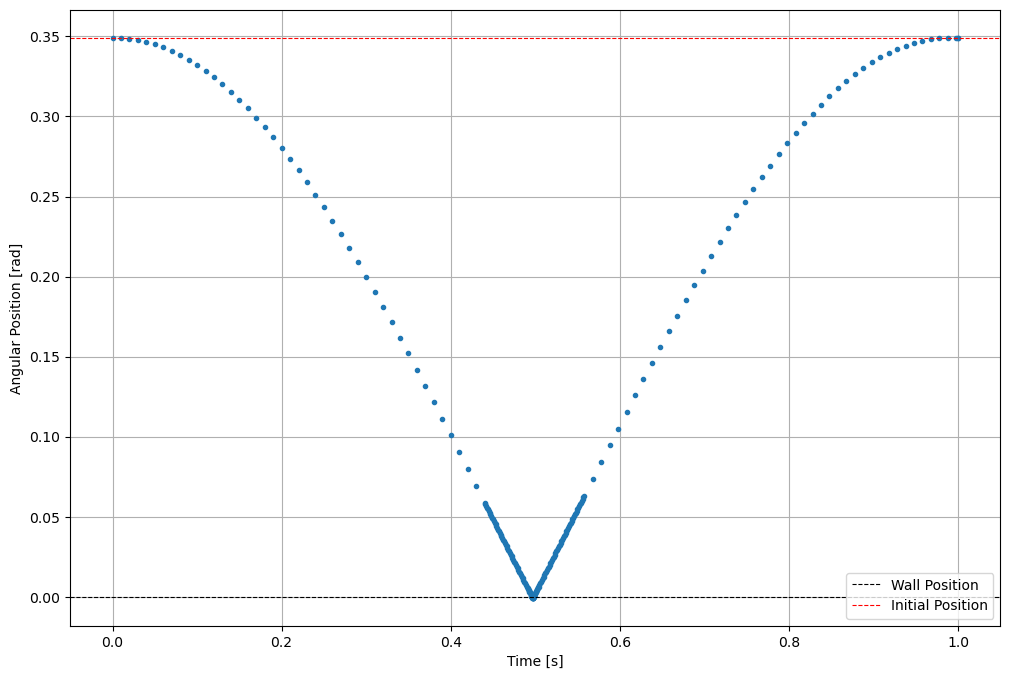

In [14]:
marker_size = 3
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}

t_vals, q_vals = zip(*model.outputs['q'].history)

plt.figure(figsize=(12, 8))
plt.plot(t_vals, q_vals, **fem_style)
plt.xlabel('Time [s]')
plt.ylabel('Angular Position [rad]')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8, label="Wall Position")
plt.axhline(q_vals[0], color='r', linestyle='--', linewidth=0.8, label='Initial Position')
plt.grid()
plt.legend(loc="lower right")
plt.show()